In [1]:
from datetime import datetime
from arcgis.features import FeatureCollection, FeatureSet
from arcgis.gis import Item
from arcgis.geoprocessing._job import GPJob

from arcgis.gis import GIS
#gis = GIS(profile="your_online_profile")
gis = GIS('https://geosaurus.maps.arcgis.com', 'arcgis_python', 'P@ssword123', verify_cert=False)

In [2]:
from arcgis.features.enrich_data import enrich_layer

<Item title:"USA Block Groups" type:Feature Layer Collection owner:esri_dm>
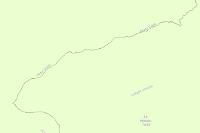

In [3]:
item = gis.content.search('title: "USA Block Groups"', 'Feature layer', outside_org=True)[0]
item

In [4]:
block_groups = item.layers[0]

In [5]:
import arcgis
arcgis.env.verbose = False

In [6]:
block_groups.filter = "STCOFIPS = '48167'"

In [9]:
import datetime
blkgrp_enrich = enrich_layer(block_groups,
#                              analysis_variables=["AtRisk.MP27002A_B","crime.CRMCYTOTC","crime.CRMCYPERC","crime.CRMCYMURD","crime.CRMCYRAPE","crime.CRMCYROBB","crime.CRMCYASST","crime.CRMCYPROC","crime.CRMCYBURG","crime.CRMCYLARC","crime.CRMCYMVEH","crime.TOTCAGG","crime.PERCAGG","crime.MURDAGG","crime.RAPEAGG","crime.ROBBAGG","crime.ASSTAGG","crime.PROCAGG","crime.BURGAGG","crime.LARCAGG","crime.MVEHAGG","LandscapeFacts.FEDLANDPT","retailmarketplace.RTSALESTOT"],
                             analysis_variables=["AtRisk.MP27002A_B"],
                             country='US',
                             output_name=f'enrich_{datetime.datetime.now().microsecond}',
                             return_boundaries=True, future=True)

In [10]:
assert isinstance(blkgrp_enrich.result(), Item)
blkgrp_enrich.result()


<Item title:"enrich_923054" type:Feature Layer Collection owner:arcgis_python>

In [11]:
blkgrp_enrich.result().delete()

True

In [12]:
point_item = gis.content.get('1f163950afbb4bf39f3ee67cf411761d')

<Item title:"Esri Regional Offices US" type:Feature Layer Collection owner:lsarow_eoe>
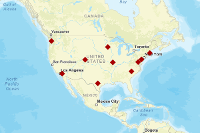

In [13]:
point_item

In [ ]:
from datetime import datetime
blkgrp_enrich = enrich_layer(point_item.layers[0],
                             analysis_variables=["AtRisk.MP27002A_B"],
                             country='US',
                             buffer_type='Walking Distance',
                             distance=4,
                             units='Meters',
                             output_name='enrich_' + str(datetime.now().microsecond),
                             return_boundaries=True)

In [ ]:
assert isinstance(blkgrp_enrich, Item)
blkgrp_enrich

In [ ]:
blkgrp_enrich.delete()